In [29]:
import vmas
import torch
import matplotlib.pyplot as plt 
from utils.map import Map, make_map_from_file, make_random_map
from utils.scenario import Scenario

In [30]:
map = Map(height=40, width=50, have_boundary=True, cell_size=1,wall_thickness=0.7)

In [31]:
map.make_random_map(num_obstacles_box= 5, num_obstacles_circle= 0, max_obstacle_length= 2,
                    min_obstacle_length= 1, max_obstacle_width=5, min_obstacle_width=4,
                    max_agent_radius=2,min_agent_radius=1,num_agents=5)

In [32]:
scenario = Scenario(map_=map)
env = vmas.make_env(
    scenario=scenario,
    num_envs=2,
    device="cpu",
    continuous_actions=True,
    wrapper=None,
    lidar_range=10.0
)
obs = env.reset()


In [33]:
def render_env(env: vmas.simulator.environment.Environment, env_idx:int):
    frame = env.render(mode="rgb_array",env_index=env_idx)
    plt.imshow(frame)
    plt.show()
    

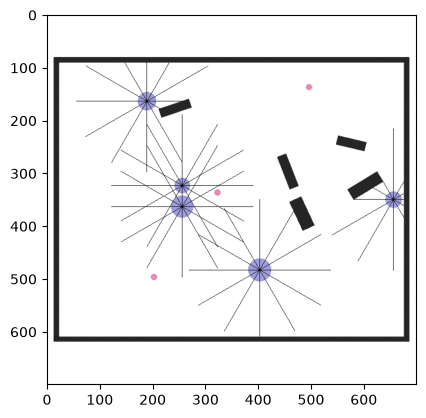

In [34]:
render_env(env,1)

In [35]:
env.world.landmarks[2].state.pos

tensor([[  0.0000, -19.6500],
        [  0.0000, -19.6500]])

## Watching Phase 1 (the CCM–FMASAC method) train

`Phase1Trainer` builds its own env internally from a `scenario_factory` (it needs a *fresh* `Scenario` per env — see `method/training/phase1.py`'s docstring), so it doesn't reuse the `map`/`scenario`/`env` above. Using `world_config.yaml` here (small, 2 agents) instead of the big random map so each iteration is fast enough to actually watch.

In [36]:
from method.buffers.replay import ReplayBuffer 

In [37]:
erp = ReplayBuffer(100)

In [38]:
erp.add(first=torch.tensor([1,3,5,6]))

## Training run results (`scripts/train.py`)

Reads the latest `runs/<timestamp>/` directory's CSV logs directly — this works whether the background run is still going or already finished (unlike `summary.png`, which is only written once at the very end). Re-run these cells any time to refresh.

In [ ]:
import pandas as pd
from pathlib import Path

def latest_run_with(fname):
    """Newest runs/<...>/ dir that actually contains `fname`.
    Skips the phase2-only / smoke run dirs that have no phase1_log.csv."""
    hits = [d for d in Path("runs").glob("*/") if (d / fname).is_file()]
    return max(hits, key=lambda d: (d / fname).stat().st_mtime) if hits else None

phase1_dir = latest_run_with("phase1_log.csv")
phase2_dir = latest_run_with("phase2_log.csv")
print("phase1 log:", phase1_dir)
print("phase2 log:", phase2_dir)

phase1_df = pd.read_csv(phase1_dir / "phase1_log.csv") if phase1_dir else None
phase2_df = pd.read_csv(phase2_dir / "phase2_log.csv") if phase2_dir else None

if phase1_df is not None:
    print(f"\nphase1: {len(phase1_df)} logged iterations")
    print(phase1_df.tail(3).to_string())
else:
    print("\nphase1: no phase1_log.csv found under runs/")

if phase2_df is not None:
    print(f"\nphase2: {len(phase2_df)} logged iterations")
    print(phase2_df.tail(3).to_string())
else:
    print("\nphase2: not started yet")


In [ ]:
if phase1_df is None:
    print("no phase1 data to plot")
else:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    axes[0, 0].plot(phase1_df["iter"], phase1_df["episode_return_agent0"])
    axes[0, 0].set_title("phase1: rollout return")

    updated = phase1_df.dropna(subset=["l_elbo"])
    axes[0, 1].plot(updated["iter"], updated["l_elbo"]); axes[0, 1].set_title("phase1: l_elbo")
    axes[0, 2].plot(updated["iter"], updated["l_cpc"]);  axes[0, 2].set_title("phase1: l_cpc")

    axes[1, 0].plot(updated["iter"], updated["exp_critic_loss"], label="exploration")
    axes[1, 0].plot(updated["iter"], updated["exe_critic_loss"], label="execution")
    axes[1, 0].set_title("phase1: critic losses"); axes[1, 0].legend()

    axes[1, 1].plot(updated["iter"], updated["l_rho"], label="l_rho")
    axes[1, 1].plot(updated["iter"], updated["l_cov"], label="l_cov")
    axes[1, 1].set_title("phase1: budget / disentanglement"); axes[1, 1].legend()

    if phase2_df is not None:
        axes[1, 2].plot(phase2_df["iter"], phase2_df["l_cpd"])
        axes[1, 2].set_title("phase2: l_cpd")
    else:
        axes[1, 2].axis("off")

    fig.tight_layout()
    plt.show()


## Load the trained model

`method/io.py` -- one place to read a trained run back from disk. `load_model()` with no args auto-picks the newest `runs/<...>/` dir that has each artifact (`phase1_checkpoint_*.pt` for Phase 1, `phase2_detector.pt` for the detector); pass explicit paths to pin a specific run. Everything comes back **frozen / eval**.


In [ ]:
from method.io import load_model, load_phase1, load_detector

# newest run, both halves:
trainer, detector = load_model()

# or pin exact checkpoints:
# trainer, detector = load_model(
#     "runs/20260906_162246/phase1_checkpoint_2999.pt",
#     "runs/20260906_182413_phase2only/phase2_detector.pt")

print("agents:", trainer.n_agents, "| code_dim:", trainer.code_dim,
      "| detector window:", detector.window, "max_len:", detector.pos_embedding.shape[1])


## Meta-test (Algorithm 10.3) on the trained model

Loads the **frozen** Phase 1 checkpoint + the retrained Phase 2 detector and runs
`MetaTestRunner` (`method/training/meta_test.py`) on scripted test episodes:

* **Scenario A** — no regime change (false-alarm control).
* **Scenario B** — agent-0 regime change (`mass 0.9→1.2`, `friction 0.03→0.15`) at step 16.

Reports detector response, reset / false-alarm behaviour, and return. Self-contained
— does not depend on the cells above. Same logic as `scripts/meta_test_eval.py`,
inline here so the per-step traces can be plotted.


In [ ]:
import json
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from utils.scenario import Scenario
from method.training.phase1 import Phase1Trainer, Phase1Config
from method.detector.indid import CausalLocalWindowTransformer
from method.training.meta_test import MetaTestRunner, MetaTestConfig, RegimeChangeEvent
from method.training.regime import Regime

PHASE1_CKPT = "runs/20260906_162246/phase1_checkpoint_2999.pt"
DETECTOR    = "runs/20260906_182413_phase2only/phase2_detector.pt"
CHANGE_STEP = 16
HORIZON     = 32
REPS        = 5

_CKPT_KEYS = ["flow","flow_momentum","budget_encoder","budget_decoder",
    "exploration_policies","exploration_critics","exploration_critics_target",
    "execution_policies","execution_critics","execution_critics_target","mixer","mixer_target"]

def load_phase1(trainer, path):
    st = torch.load(path, map_location=trainer.device)
    for k in _CKPT_KEYS:
        if k in st:
            getattr(trainer, k).load_state_dict(st[k])
        elif k.endswith("_target"):
            getattr(trainer, k).load_state_dict(getattr(trainer, k[:-7]).state_dict())
    for n in ("log_alpha_exp", "log_alpha_exe"):
        if n in st:
            with torch.no_grad():
                getattr(trainer, n).copy_(st[n])

prev = json.loads((Path(PHASE1_CKPT).parent / "args.json").read_text())
trainer = Phase1Trainer(lambda: Scenario(config_file="world_config.yaml"),
                        Phase1Config(n_envs=prev["n_envs"], horizon=prev["horizon"]))
load_phase1(trainer, PHASE1_CKPT)
N = trainer.n_agents

detector = CausalLocalWindowTransformer(
    code_dim=trainer.code_dim, d_model=64, n_heads=4, n_layers=2,
    window=16, max_len=trainer.cfg.horizon + 1).to(trainer.device)
detector.load_state_dict(torch.load(DETECTOR, map_location=trainer.device))
detector.eval()

NOMINAL = Regime(mass=0.9, linear_friction=0.03)
SHIFTED = Regime(mass=1.2, linear_friction=0.15)
MTCFG   = MetaTestConfig()
print("MetaTestConfig:", MTCFG)

def run_episode(events, seed):
    torch.manual_seed(seed)
    r = MetaTestRunner(trainer, detector,
                       lambda: Scenario(config_file="world_config.yaml"), MTCFG)
    r.schedule(events)
    r.reset_state()
    rows = []
    for t in range(HORIZON):
        s = r.step(render=False)
        for i in range(N):
            rows.append(dict(step=t, agent=i, p=s.detector_p[i],
                             mode=s.mode[i], reset=bool(s.reset_fired[i]),
                             reward=float(s.rewards[i])))
    return pd.DataFrame(rows)

control, change = [], []
for rep in range(REPS):
    ev_a = [RegimeChangeEvent(0, i, NOMINAL) for i in range(N)]
    ev_b = ev_a + [RegimeChangeEvent(CHANGE_STEP, 0, SHIFTED)]
    control.append(run_episode(ev_a, 1000 + rep))
    change.append(run_episode(ev_b, 2000 + rep))

def summarise(dfs, label, change_step=None):
    rows = []
    for rep, df in enumerate(dfs):
        resets = df[df.reset]
        if change_step is None:
            fa, delay = len(resets), None
        else:
            fa = len(resets[(resets.agent == 0) & (resets.step < change_step)])
            post = resets[(resets.agent == 0) & (resets.step >= change_step)]
            delay = int(post.step.min() - change_step) if len(post) else None
        rows.append(dict(rep=rep, ret=round(df.reward.sum(), 3),
                         false_alarms=fa, detect_delay=delay))
    t = pd.DataFrame(rows)
    print(f"\n--- {label} ---")
    print(t.to_string(index=False))
    if change_step is None:
        print(f"  false-alarm resets/ep: mean={t.false_alarms.mean():.2f} "
              f"({t.false_alarms.mean()/HORIZON:.3f}/step)")
    else:
        d = t.detect_delay.dropna()
        print(f"  detected {len(d)}/{len(t)} | delay mean={d.mean():.1f} median={d.median():.1f} "
              f"| pre-change false alarms/ep={t.false_alarms.mean():.2f}")
    return t

summ_a = summarise(control, "SCENARIO A: no change (false-alarm control)")
summ_b = summarise(change,  f"SCENARIO B: agent-0 change at step {CHANGE_STEP}", CHANGE_STEP)


MetaTestConfig: MetaTestConfig(threshold_C=0.5, re_exploration_budget_K=8, sigma2_min=0.05, eps_pos=0.2, beta_pos=0.05, eps_action=0.1, beta_action=0.05, pgd_steps=1)

--- SCENARIO A: no change (false-alarm control) ---
 rep   ret  false_alarms detect_delay
   0 -1.28             2         None
   1 -1.28             4         None
   2 -1.28             4         None
   3 -1.28             4         None
   4 -1.28             2         None
  false-alarm resets/ep: mean=3.20 (0.100/step)

--- SCENARIO B: agent-0 change at step 16 ---
 rep   ret  false_alarms  detect_delay
   0 -1.28             1           NaN
   1 -1.28             1           1.0
   2 -1.28             1          13.0
   3 -1.28             1           6.0
   4 -1.28             1          11.0
  detected 4/5 | delay mean=7.8 median=8.5 | pre-change false alarms/ep=1.00


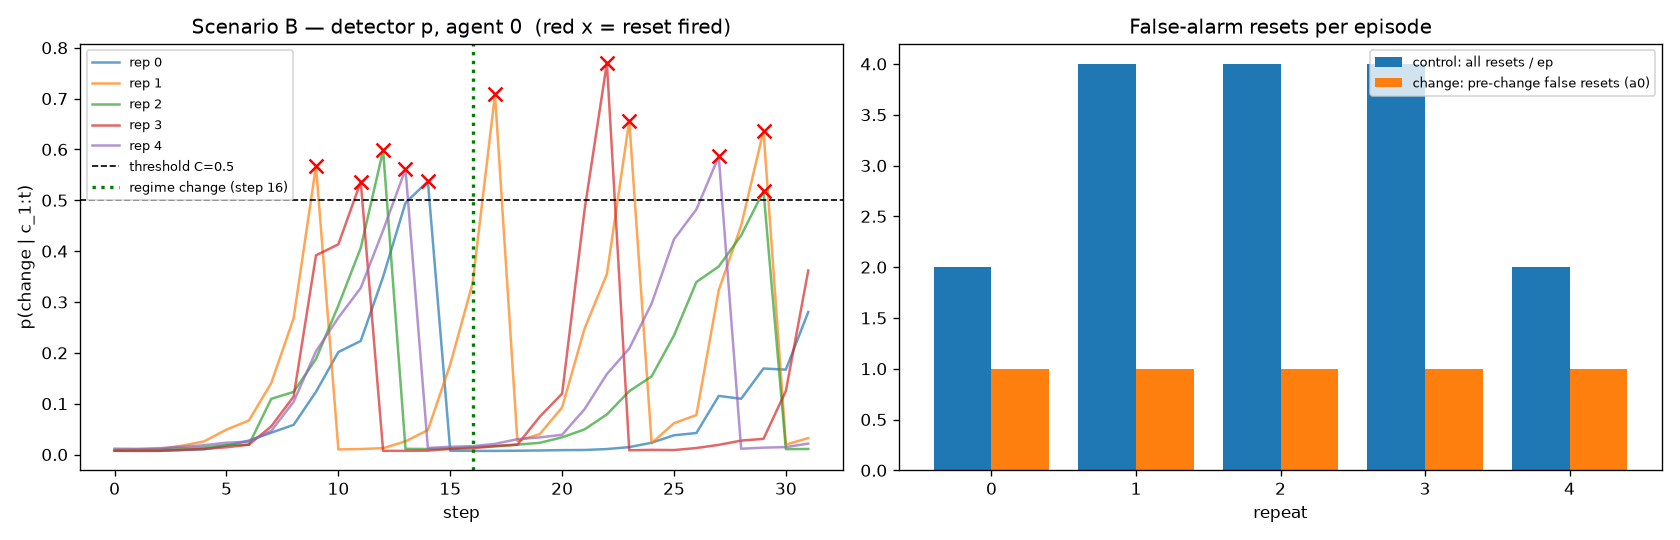

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

for rep, df in enumerate(change):
    a0 = df[df.agent == 0]
    ax[0].plot(a0.step, a0.p, alpha=0.7, label=f"rep {rep}")
    hit = a0[a0.reset]
    ax[0].scatter(hit.step, hit.p, marker="x", s=70, color="red", zorder=5)
ax[0].axhline(MTCFG.threshold_C, ls="--", c="k", lw=1, label=f"threshold C={MTCFG.threshold_C}")
ax[0].axvline(CHANGE_STEP, ls=":", c="green", lw=2, label=f"regime change (step {CHANGE_STEP})")
ax[0].set_title("Scenario B — detector p, agent 0  (red x = reset fired)")
ax[0].set_xlabel("step"); ax[0].set_ylabel("p(change | c_1:t)")
ax[0].legend(fontsize=8)

ctrl_fa = [int(df.reset.sum()) for df in control]
chg_fa  = [int(df[(df.reset) & (df.agent == 0) & (df.step < CHANGE_STEP)].shape[0]) for df in change]
x = np.arange(REPS)
ax[1].bar(x - 0.2, ctrl_fa, 0.4, label="control: all resets / ep")
ax[1].bar(x + 0.2, chg_fa, 0.4, label="change: pre-change false resets (a0)")
ax[1].set_title("False-alarm resets per episode")
ax[1].set_xlabel("repeat"); ax[1].set_xticks(x)
ax[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


### Meta-test video

Annotated render of one scripted meta-test episode: the VMAS environment (agents, lidar rays, obstacles, victim) plus a per-step overlay of each agent's mode / detector `p` / reset, and the scripted regime-change marker. Generated by `scripts/record_metatest_video.py`. The `change` scenario is embedded below; run the last cell for the no-change `control` clip.


In [ ]:
# Meta-test video -- render a scripted test episode as an annotated mp4.
# (scripts/record_metatest_video.py). ~1-2 min per scenario; skips if the mp4 exists.
import subprocess, sys
from pathlib import Path

CKPT = "runs/20260906_162246/phase1_checkpoint_2999.pt"
DET  = "runs/20260906_182413_phase2only/phase2_detector.pt"

for scen in ["change", "control"]:            # also: "attack"
    out = f"runs/metatest_{scen}.mp4"
    if Path(out).exists():
        print("exists:", out); continue
    subprocess.run([sys.executable, "scripts/record_metatest_video.py",
                    "--phase1-ckpt", CKPT, "--detector", DET,
                    "--scenario", scen, "--fps", "3", "--out", out], check=True)


exists: runs/metatest_change.mp4
exists: runs/metatest_control.mp4


In [ ]:
from IPython.display import Video
Video("runs/metatest_change.mp4", embed=True, width=820)


In [ ]:
Video("runs/metatest_control.mp4", embed=True, width=820)


### Interactive playback (whole episode, whole arena)

`method/viz.play(...)` runs one scripted meta-test episode **to its real end** (victim rescued, or victim health decays to 0 -> `done`; ~500 steps for the current model) on the **full arena** (`viewer_zoom` widens the camera past the 10x10 map so the walls are visible), and returns a matplotlib animation. `HTML(anim.to_jshtml())` renders a JS player: **play / pause / step / frame slider / loop / fps**, no ipywidgets.

Each frame = the VMAS render + a per-step overlay: each agent's mode / detector `p` / reset, the **victim health**, `rescued` flag, and an `EPISODE ENDED` marker. `play()` also prints an outcome summary (steps, end reason, rescued?, cumulative reward, detector resets).

Knobs: `scenario` = `"control"|"change"|"attack"`, `seed`, `viewer_zoom` (bigger = wider view), `fps`, `max_steps`.

In [ ]:
from method.viz import play
from IPython.display import HTML

# runs the FULL episode (until the victim is rescued or dies), full arena.
anim = play(trainer, detector, scenario="change", seed=2000, viewer_zoom=2.65, fps=8)
HTML(anim.to_jshtml())


### A rescue episode (scripted controller)

The trained policy never rescues the victim (see the playback above -- its agents don't navigate to it). `method/viz.rescue_demo()` swaps the policy for a scripted *drive-straight-at-the-victim* controller so the **rescue path** is visible: agents converge, one gets within `rescue_range=0.5`, the victim's health **freezes**, the rescuer gets `rescue_reward x health/100` (reward goes **positive**), and `done` fires early with `victim_rescued = True`. This is *not* the trained model -- it shows what a successful episode looks like and that the rescue mechanics work.

In [ ]:
from method.viz import rescue_demo
from IPython.display import HTML

anim = rescue_demo(seed=0, which_agents="all", fps=10)
HTML(anim.to_jshtml())
